# K-Means with SKLearn

**Creating data derived from iris**<br>
Normalizing is recommended if you have values of different units

In [1]:
%matplotlib inline
import os     
os.environ["OMP_NUM_THREADS"] = "1"  # to remove a warning because of a bug in KMeans
import pandas as pd
import numpy as np
import mglearn
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler 

iris = datasets.load_iris()

X = iris.data[:,2:4] # reduce dimensions
X = MinMaxScaler().fit_transform(X)
print("Shape", X.shape)

Shape (150, 2)


**Vizualization functions**

In [2]:
# paints cluster centers and classified points
def plotCluster(X, y, centroids):
    """
    Works up to 7 clusters / 7 Colors
    """
    #up to 4 colors stacked 2 times 
    cm_cycle = ['#7070ff', '#ff5050', '#70ffff', '#70aaaa', '#aa5050', '#70aaff', '#70aa70']
    cm_cycle = cm_cycle[:len(np.unique(y))]
    cm_cycle = np.hstack((cm_cycle, cm_cycle))
    
    markers=np.hstack((['o']*len(np.unique(y)),['X']*len(np.unique(y)))) 

    Xplot = np.vstack((X,centroids))
    yplot = np.hstack((y,np.arange(len(centroids))%len(X)+len(X)))

    plt.figure(figsize=(12,9))
    mglearn.discrete_scatter(Xplot[:, 0], Xplot[:, 1], yplot, markers=markers, c=cm_cycle)
    plt.show()
print("Plotting function defined")

Plotting function defined


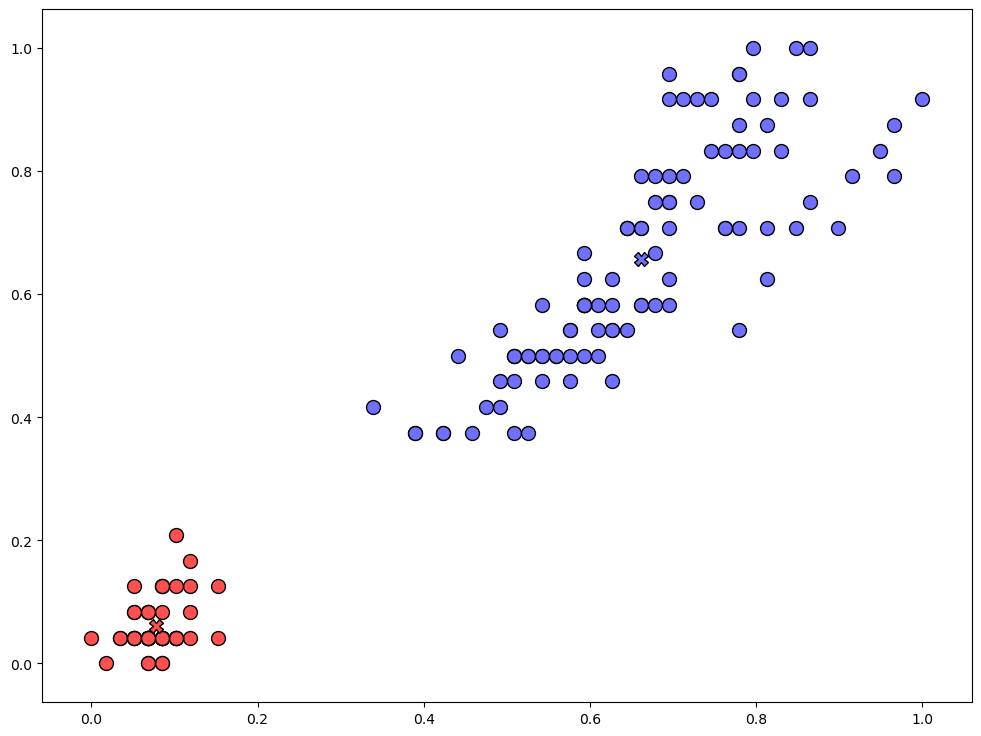

In [3]:
from sklearn.cluster import KMeans

means=KMeans(n_clusters=2)
y= means.fit_predict(X);
plotCluster(X,y,means.cluster_centers_)

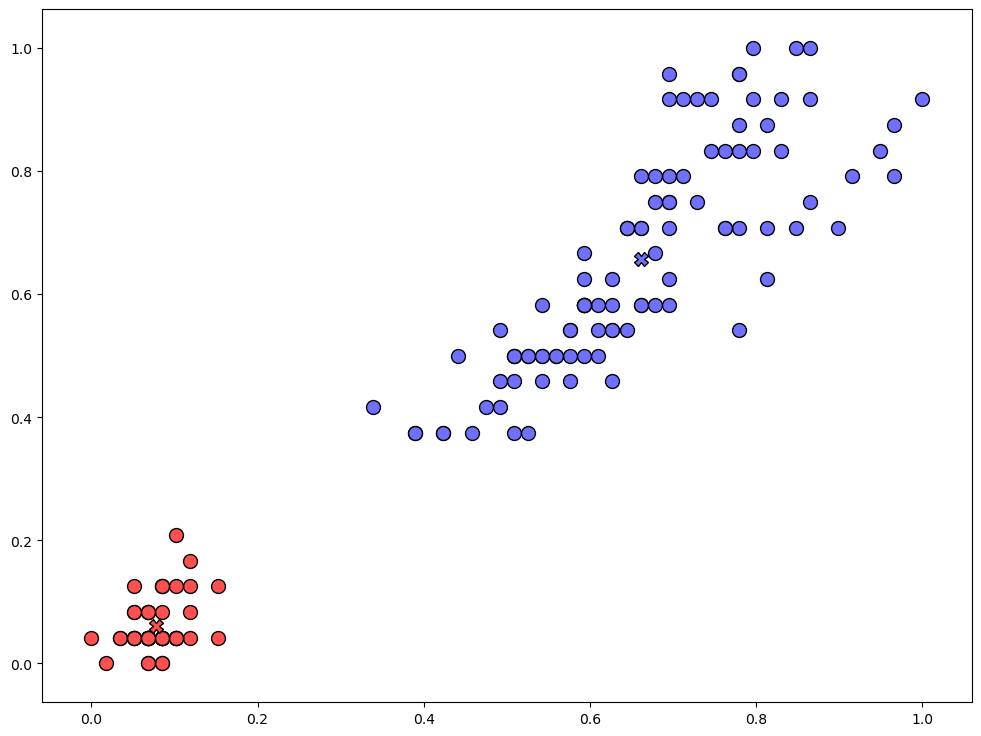

In [4]:
from sklearn.cluster import KMeans

means=KMeans(n_clusters=2)
means.fit(X);
y = means.predict(X)
plotCluster(X,y,means.cluster_centers_)

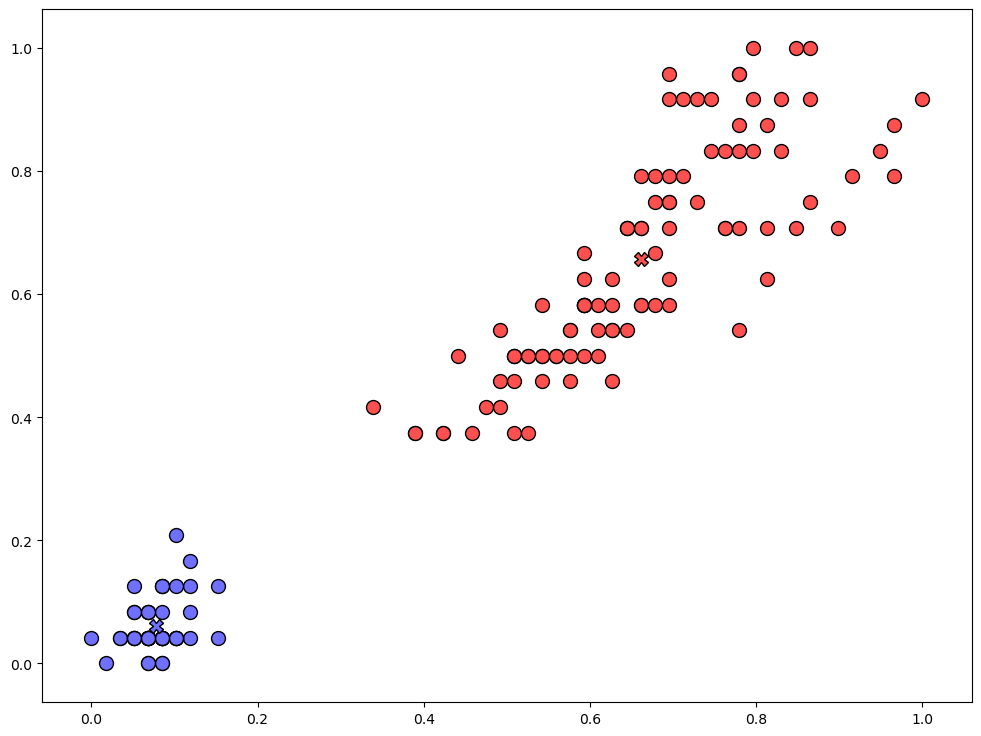

This needed 7 iterations


In [12]:
from sklearn.cluster import KMeans

means=KMeans(n_clusters=2,random_state=0)
y = means.fit_predict(X);
plotCluster(X,y,means.cluster_centers_)
print("This needed {} iterations".format(means.n_iter_))

In [13]:
means.transform(X).shape

(150, 2)